# Exploratory Data Analysis: Bird Diversity & Environmental Factors
This notebook explores the relationship between various bird species and their environmental preferences in Sri Lanka based on the dataset.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

In [69]:
import os
data_path = '../file6.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at {data_path}")

print("Loading data...")
df = pd.read_csv(data_path)
print(f"Original Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head()


Loading data...
Original Data loaded: 1552048 rows, 24 columns


,index,verbatimScientificName,stateProvince,individualCount,decimalLatitude,decimalLongitude,eventDate,avg_rad,NDVI_raw,LandCover_Class,...,Sulfate_Mass,Sea_Salt_Mass,Total_Aerosol_Extinction,temp_mean,rainfall,wind_mean,humid_mean,shortwave_radiation,lka_general_2020,NDVI
0,0,Anarhynchus alexandrinus,Mannar,8.0,9.058512,79.85502,2021-01-06,0.66,3792.0,10,...,3.372161e-09,3.725563e-08,0.175115,26.58,15.17,1.31,85.53,17.65,2.805795,0.3792
1,2,Hirundo rustica,Colombo,10.0,6.866285,79.93144,2024-12-23,10.16,7045.0,13,...,4.424376e-09,3.249729e-08,0.198127,26.21,0.25,2.51,84.30,20.49,8.917330,0.7045
2,6,Corvus macrorhynchos,Matara,2.0,5.983496,80.52548,2024-10-12,1.26,6989.0,10,...,7.456183e-10,5.362027e-08,0.131458,26.91,14.47,5.18,83.81,15.67,2.768103,0.6989
3,7,Dicrurus caerulescens,Matale,1.0,7.969125,80.75477,2021-11-20,0.37,8543.0,8,...,1.612494e-09,3.017664e-08,0.123156,25.30,2.54,2.98,89.54,21.99,3.339740,0.8543
4,8,Threskiornis melanocephalus,Jaffna,30.0,9.637712,79.95190,2019-03-25,0.52,4000.0,10,...,2.737918e-09,3.224930e-08,0.220155,29.67,0.00,4.65,63.33,24.53,3.209018,0.4000


### Top Frequently Observed Bird Species

### Relationship Between Bird Species and Geography (Elevation)

In [70]:
df.columns

Index(['index', 'verbatimScientificName', 'stateProvince', 'individualCount',
       'decimalLatitude', 'decimalLongitude', 'eventDate', 'avg_rad',
       'NDVI_raw', 'LandCover_Class', 'elevation_meters', 'Carbon_Mass',
       'Dust_Mass', 'SO2_Mass', 'Sulfate_Mass', 'Sea_Salt_Mass',
       'Total_Aerosol_Extinction', 'temp_mean', 'rainfall', 'wind_mean',
       'humid_mean', 'shortwave_radiation', 'lka_general_2020', 'NDVI'],
      dtype='str')

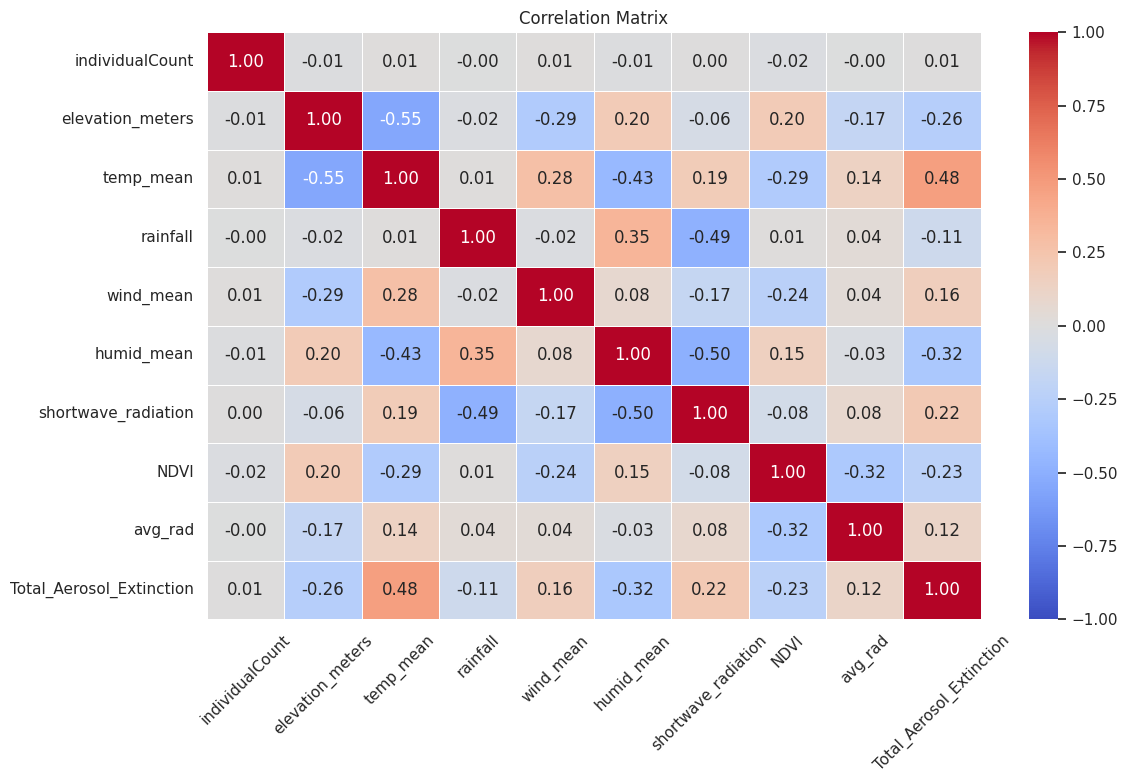

In [71]:
features_with_target = [
    'individualCount', 'elevation_meters', 'temp_mean', 'rainfall',
    'wind_mean', 'humid_mean', 'shortwave_radiation',
    'NDVI', 'avg_rad', 'Total_Aerosol_Extinction'
]

plt.figure(figsize=(12, 8))
corr_all = df[features_with_target].corr()

sns.heatmap(corr_all, annot=True, cmap='coolwarm',
            fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [72]:
features = [
    'individualCount', 'elevation_meters', 'temp_mean', 'rainfall',
    'wind_mean', 'humid_mean', 'shortwave_radiation',
    'NDVI', 'avg_rad', 'Total_Aerosol_Extinction'
]

species_list = df['verbatimScientificName'].unique()

threshold = 0.5
rows = []

for species in species_list:
    df_species = df[df['verbatimScientificName'] == species]
    
    # Skip small datasets
    if len(df_species) < 10:
        continue
    
    corr = df_species[features].corr()
    target_corr = corr['individualCount'].drop('individualCount')
    
    # Filter strong correlations
    strong_features = target_corr[abs(target_corr) >= threshold]
    
    for feature, value in strong_features.items():
        rows.append({
            'species': species,
            'feature': feature,
            'correlation': value
        })

# Final DataFrame
result_df = pd.DataFrame(rows)

# Sort by absolute correlation (strongest first)
result_df['abs_corr'] = result_df['correlation'].abs()
result_df = result_df.sort_values(by='abs_corr', ascending=False).drop(columns='abs_corr')

result_df

,species,feature,correlation
36,Tringa erythropus,rainfall,-0.997400
35,Tringa erythropus,temp_mean,-0.994907
37,Tringa erythropus,shortwave_radiation,-0.992632
39,Tringa erythropus,Total_Aerosol_Extinction,-0.974924
28,Anas platyrhynchos,humid_mean,-0.901653
24,Ardenna carneipes,avg_rad,0.864768
17,Delichon dasypus,shortwave_radiation,-0.842675
16,Delichon dasypus,wind_mean,-0.802424
38,Tringa erythropus,avg_rad,-0.773050
3,Merops persicus,rainfall,-0.742238


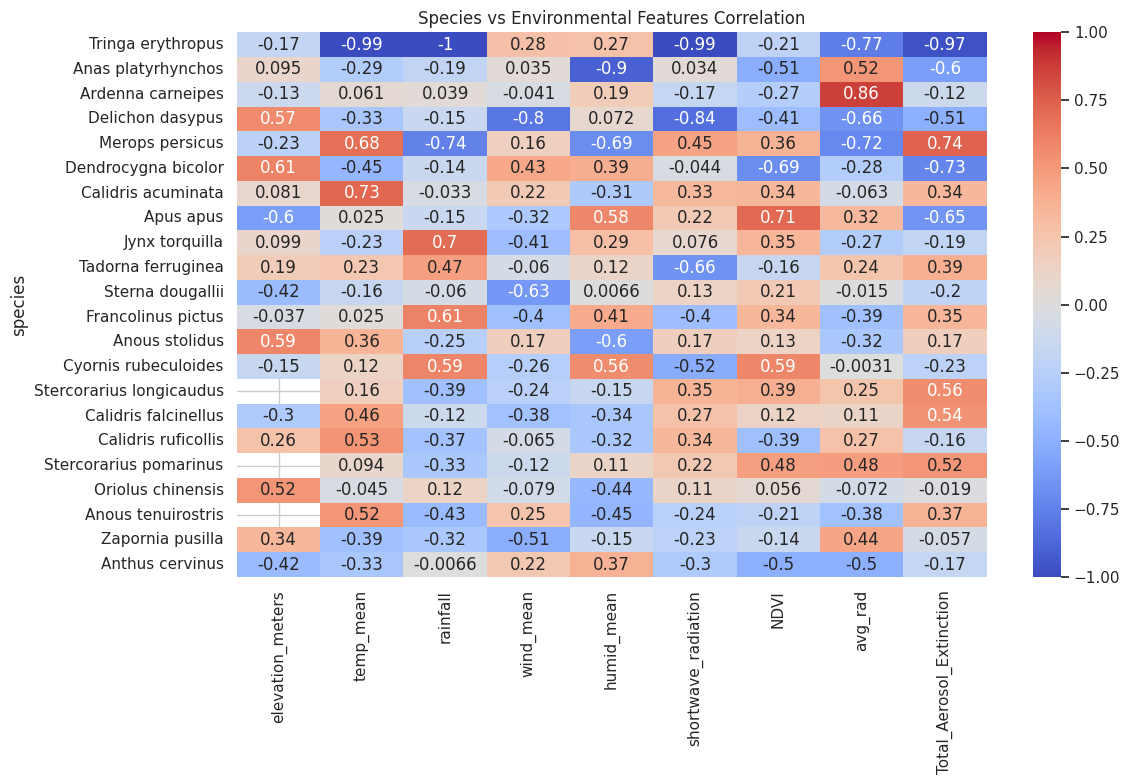

In [73]:
rows = []

for species in result_df['species'].unique():
    df_species = df[df['verbatimScientificName'] == species]
    
    if len(df_species) < 10:
        continue
    
    corr = df_species[features].corr()
    row = corr['individualCount'].drop('individualCount')
    row['species'] = species
    
    rows.append(row)

final_matrix = pd.DataFrame(rows)
final_matrix.set_index('species', inplace=True)

plt.figure(figsize=(12, 8))
sns.heatmap(final_matrix, annot=True, cmap='coolwarm',
            vmin=-1, vmax=1)

plt.title('Species vs Environmental Features Correlation')
plt.tight_layout()
plt.show()